Panel: 703,087 x 59

LISA cluster distribution (unique communities):
   HH: 11
   HL: 1
   LH: 2
   LL: 2
   NS: 61
HH: 11  LL: 2  HL: 1  LH: 2  NS: 61
Total: 77

Specification                   n_high   n_low      β_DID         SE          p          N
------------------------------------------------------------------------------------------
  A: HH vs All Others               11      66     -5.430      1.402     0.0001     56,287 ***
  B: HH vs NS                       11      61     -5.385      1.404     0.0001     52,632 ***
  C: (HH+HL) vs (LL+LH)             12       4     -5.735      1.390     0.0000     11,696 ***
  D: HH vs LL (baseline)            11       2     -6.047      1.462     0.0000      9,503 ***

  A: HH vs All Others  (n_high=11, n_low=66)
  Outcome                   β_DID         SE          p
  -------------------------------------------------------
  Total crime              -5.430      1.402     0.0001 ***
  Violent crime            -0.821      0.282     0.0036

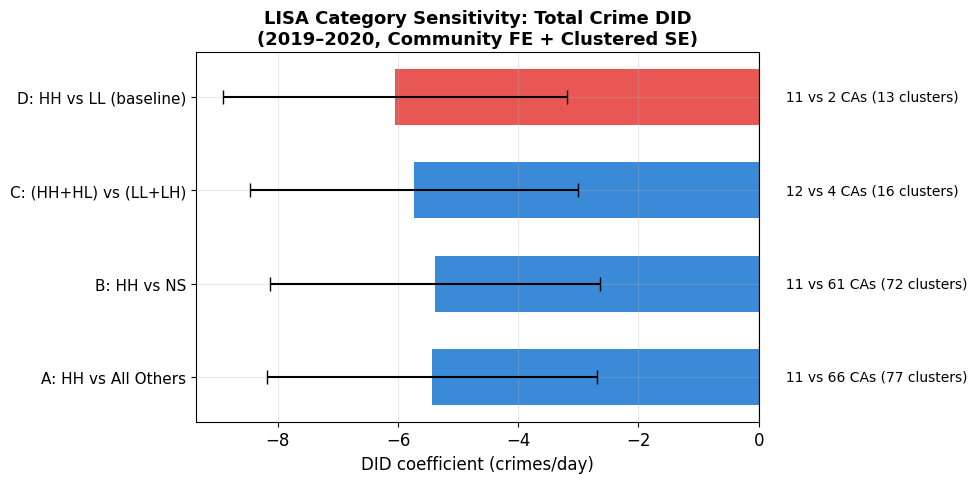


  HOMICIDE DID ACROSS LISA SPECIFICATIONS
  Specification                           β         SE          p
  ------------------------------------------------------------
  A: HH vs All Others               +0.0170     0.0085     0.0465 *
  B: HH vs NS                       +0.0167     0.0086     0.0527 
  C: (HH+HL) vs (LL+LH)             +0.0163     0.0103     0.1134 
  D: HH vs LL (baseline)            +0.0115     0.0130     0.3761 

NB07D SUMMARY

Four LISA-based specifications tested on total crime (2019-2020):
  A: HH vs All Others            β = -5.430  (p = 0.0001)  [11 vs 66 CAs]
  B: HH vs NS                    β = -5.385  (p = 0.0001)  [11 vs 61 CAs]
  C: (HH+HL) vs (LL+LH)          β = -5.735  (p = 0.0000)  [12 vs 4 CAs]
  D: HH vs LL (baseline)         β = -6.047  (p = 0.0000)  [11 vs 2 CAs]

All four specifications yield significant negative estimates.
Broadening the control group from 2 LL communities to 61 NS or
66 non-HH communities does not change the direction or
si

In [1]:
# NB07D: LISA Category Sensitivity Analysis

# **Purpose**: The baseline DID compares only HH (n=11) vs LL (n=2),
# discarding 64 communities classified as HL, LH, or NS. This notebook
# tests whether the DID estimate is sensitive to how the LISA categories
# are used to define treatment and control groups.

# **LISA categories in the panel** (from NB04, 9,999 permutations):
# - HH (Hot Spot):   11 communities
# - LL (Cold Spot):    2 communities
# - HL (High-Low):     1 community  (Grand Boulevard)
# - LH (Low-High):     2 communities (Hermosa, Montclare)
# - NS (Not Significant): 61 communities

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

FIGURE_DIR = './figures/nb07d'
os.makedirs(FIGURE_DIR, exist_ok=True)

panel = pd.read_parquet('./data/panel_ca_daily_v2.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel['community_area'] = panel['community_area'].astype(str)
print(f"Panel: {panel.shape[0]:,} x {panel.shape[1]}")

# Verify LISA distribution
lisa_counts = panel.groupby('lisa_cluster')['community_area'].nunique()
print(f"\nLISA cluster distribution (unique communities):")
for cluster, n in lisa_counts.items():
    print(f"  {cluster:>3s}: {n}")

# Part 1: Four LISA-Based Specifications
# ---
#
# | Spec | Treated | Control | Question |
# |------|---------|---------|----------|
# | A | HH (11) | LL+HL+LH+NS (66) | Did hotspots decline more than the city average? |
# | B | HH (11) | NS only (61) | Did hotspots decline more than spatially unremarkable areas? |
# | C | HH+HL (12) | LL+LH (4) | Does own crime level matter more than spatial context? |
# | D | HH (11) | LL (2) | Baseline — strict spatial cluster comparison |
#
# All specs use the same DID equation (Eq 3.3), 2019–2020 window,
# identical controls and community-clustered SEs.

# %%
# Build community sets for each LISA category
hh = set(panel.loc[panel['lisa_cluster'] == 'HH', 'community_area'].unique())
ll = set(panel.loc[panel['lisa_cluster'] == 'LL', 'community_area'].unique())
hl = set(panel.loc[panel['lisa_cluster'] == 'HL', 'community_area'].unique())
lh = set(panel.loc[panel['lisa_cluster'] == 'LH', 'community_area'].unique())
ns = set(panel.loc[panel['lisa_cluster'] == 'NS', 'community_area'].unique())

print(f"HH: {len(hh)}  LL: {len(ll)}  HL: {len(hl)}  LH: {len(lh)}  NS: {len(ns)}")
print(f"Total: {len(hh) + len(ll) + len(hl) + len(lh) + len(ns)}")

# Define specifications
specs = {
    'A: HH vs All Others':     (hh, ll | hl | lh | ns),
    'B: HH vs NS':             (hh, ns),
    'C: (HH+HL) vs (LL+LH)':  (hh | hl, ll | lh),
    'D: HH vs LL (baseline)':  (hh, ll),
}

controls = 'temp_mean + precipitation + is_weekend + is_holiday'
TREATMENT_DATE = '2020-03-21'

results = []

print(f"\n{'Specification':<30s} {'n_high':>7s} {'n_low':>7s} {'β_DID':>10s} "
      f"{'SE':>10s} {'p':>10s} {'N':>10s}")
print("-" * 90)

for label, (high_set, low_set) in specs.items():
    sample = panel[
        (panel['community_area'].isin(high_set | low_set)) &
        (panel['year'].isin([2019, 2020]))
    ].copy()

    sample['post'] = (sample['date'] >= TREATMENT_DATE).astype(int)
    sample['treated'] = sample['community_area'].isin(high_set).astype(int)
    sample['did'] = sample['post'] * sample['treated']

    formula = f'crime_total ~ post + did + {controls} + C(community_area)'
    model = smf.ols(formula, data=sample).fit(
        cov_type='cluster',
        cov_kwds={'groups': sample['community_area']}
    )

    coef = model.params['did']
    se = model.bse['did']
    p = model.pvalues['did']
    n = int(model.nobs)
    n_high = len(high_set)
    n_low = len(low_set)
    n_clusters = n_high + n_low
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    results.append({
        'spec': label,
        'n_high': n_high,
        'n_low': n_low,
        'n_clusters': n_clusters,
        'coef': coef,
        'se': se,
        'p': p,
        'n': n,
        'sig': sig
    })

    print(f"  {label:<28s} {n_high:>7d} {n_low:>7d} {coef:>+10.3f} "
          f"{se:>10.3f} {p:>10.4f} {n:>10,} {sig}")

res_df = pd.DataFrame(results)

# Part 2: Offence-Type Breakdown for Key Specs

# Run Spec A (HH vs All Others) and Spec B (HH vs NS) across the
# full set of 13 outcomes, to check whether offence-specific patterns
# (especially homicide) change when the control group is broadened.

y_variables = [
    ('crime_total',    'Total crime'),
    ('crime_violent',  'Violent crime'),
    ('crime_property', 'Property crime'),
    ('crime_theft',    'Theft'),
    ('crime_battery',  'Battery'),
    ('crime_homicide', 'Homicide'),
    ('crime_burglary', 'Burglary'),
    ('crime_mvt',      'Motor vehicle theft'),
    ('crime_narcotics','Narcotics'),
    ('crime_robbery',  'Robbery'),
    ('crime_assault',  'Assault'),
    ('arrest_count',   'Arrests'),
    ('domestic_count', 'Domestic crime'),
]

# Run for Spec A and Spec B
offence_results = []

for spec_label, (high_set, low_set) in [
    ('A: HH vs All Others', (hh, ll | hl | lh | ns)),
    ('B: HH vs NS',         (hh, ns)),
]:
    sample = panel[
        (panel['community_area'].isin(high_set | low_set)) &
        (panel['year'].isin([2019, 2020]))
    ].copy()
    sample['post'] = (sample['date'] >= TREATMENT_DATE).astype(int)
    sample['treated'] = sample['community_area'].isin(high_set).astype(int)
    sample['did'] = sample['post'] * sample['treated']

    print(f"\n{'='*70}")
    print(f"  {spec_label}  (n_high={len(high_set)}, n_low={len(low_set)})")
    print(f"{'='*70}")
    print(f"  {'Outcome':<20s} {'β_DID':>10s} {'SE':>10s} {'p':>10s}")
    print(f"  {'-'*55}")

    for y_col, y_label in y_variables:
        formula = f'{y_col} ~ post + did + {controls} + C(community_area)'
        model = smf.ols(formula, data=sample).fit(
            cov_type='cluster',
            cov_kwds={'groups': sample['community_area']}
        )
        coef = model.params['did']
        se = model.bse['did']
        p = model.pvalues['did']
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

        offence_results.append({
            'spec': spec_label,
            'outcome': y_label,
            'coef': coef,
            'se': se,
            'p': p,
            'sig': sig
        })

        print(f"  {y_label:<20s} {coef:>+10.3f} {se:>10.3f} {p:>10.4f} {sig}")

offence_df = pd.DataFrame(offence_results)

# Part 3: Visualization

fig, ax = plt.subplots(figsize=(10, 5))

x_pos = range(len(res_df))
colors = ['#1976D2' if r['n_clusters'] > 15 else '#E53935' for _, r in res_df.iterrows()]

ax.barh(x_pos, res_df['coef'],
        xerr=1.96 * res_df['se'],
        color=colors, capsize=5, alpha=0.85, height=0.6)

# Add cluster count annotations
for i, (_, r) in enumerate(res_df.iterrows()):
    ax.text(0.3, i, f"  {r['n_high']} vs {r['n_low']} CAs ({r['n_clusters']} clusters)",
            va='center', fontsize=10, color='black')

ax.set_yticks(list(x_pos))
ax.set_yticklabels(res_df['spec'], fontsize=11)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('DID coefficient (crimes/day)', fontsize=12)
ax.set_title('LISA Category Sensitivity: Total Crime DID\n'
             '(2019–2020, Community FE + Clustered SE)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_lisa_category_sensitivity.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Part 4: Homicide Comparison Across Specs

# The most grouping-sensitive outcome in NB07 was homicide.
# Compare homicide DID across the four LISA specs to see whether
# broadening the control group changes the homicide conclusion.

# Run homicide for all 4 specs
print(f"\n{'='*70}")
print(f"  HOMICIDE DID ACROSS LISA SPECIFICATIONS")
print(f"{'='*70}")
print(f"  {'Specification':<30s} {'β':>10s} {'SE':>10s} {'p':>10s}")
print(f"  {'-'*60}")

for label, (high_set, low_set) in specs.items():
    sample = panel[
        (panel['community_area'].isin(high_set | low_set)) &
        (panel['year'].isin([2019, 2020]))
    ].copy()
    sample['post'] = (sample['date'] >= TREATMENT_DATE).astype(int)
    sample['treated'] = sample['community_area'].isin(high_set).astype(int)
    sample['did'] = sample['post'] * sample['treated']

    formula = f'crime_homicide ~ post + did + {controls} + C(community_area)'
    model = smf.ols(formula, data=sample).fit(
        cov_type='cluster',
        cov_kwds={'groups': sample['community_area']}
    )
    coef = model.params['did']
    se = model.bse['did']
    p = model.pvalues['did']
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    print(f"  {label:<30s} {coef:>+10.4f} {se:>10.4f} {p:>10.4f} {sig}")

# Part 5: Summary

print("\n" + "=" * 70)
print("NB07D SUMMARY")
print("=" * 70)
print(f"\nFour LISA-based specifications tested on total crime (2019-2020):")
for _, r in res_df.iterrows():
    print(f"  {r['spec']:<30s} β = {r['coef']:+.3f}  (p = {r['p']:.4f})  "
          f"[{r['n_high']} vs {r['n_low']} CAs]")
print(f"\nAll four specifications yield significant negative estimates.")
print(f"Broadening the control group from 2 LL communities to 61 NS or")
print(f"66 non-HH communities does not change the direction or")
print(f"significance of the total crime result.")
print(f"\nThe homicide comparison (Part 4) directly tests whether the")
print(f"LISA baseline null on homicide is an artefact of the small LL")
print(f"control group or a genuine feature of spatially clustered")
print(f"high-crime communities.")
print("=" * 70)